# Task 3 Prototype: Jurisdiction-Aware AI Credit Governance Tool

Student: ZHANG JUNYI  
Matriculation ID: G2505266E  
Email: JUNYI006@e.ntu.edu.sg

This notebook demonstrates the core logic of a jurisdiction-aware RegTech prototype for AI credit scoring governance. It uses the generated CSV files in the `data/` folder.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
PROJECT_ROOT = next(
    root for root in candidate_roots
    if (root / "data" / "Task3_synthetic_credit_applications.csv").exists()
)
DATA_DIR = PROJECT_ROOT / "data"

applications = pd.read_csv(DATA_DIR / "Task3_synthetic_credit_applications.csv")
rules = pd.read_csv(DATA_DIR / "Task3_jurisdiction_rules.csv")
metrics = pd.read_csv(DATA_DIR / "Task3_fairness_metrics_by_jurisdiction.csv")
outputs = pd.read_csv(DATA_DIR / "Task3_model_outputs.csv")
sensitivity = pd.read_csv(DATA_DIR / "Task3_sensitivity_analysis.csv")
shap_explanations = pd.read_csv(DATA_DIR / "Task3_shap_explanations.csv")
model_comparison = pd.read_csv(DATA_DIR / "Task3_model_comparison.csv")
rf_importance = pd.read_csv(DATA_DIR / "Task3_random_forest_feature_importance.csv")

print(f"Loaded data from: {DATA_DIR}")

applications.head()


Loaded data from: /Users/zhangjunyi/Desktop/6822 Assignment1/data


,applicant_id,jurisdiction,age,age_group,gender,protected_group,income,employment_status,credit_score,debt_to_income,...,loan_term_months,loan_purpose,prior_default,region_risk_score,default_next_12m,model_score,approved,manual_review,decision_reason_1,decision_reason_2
0,APP-00001,US,37,35-49,Male,1,32701,Unemployed,597,0.261,...,24,Credit card consolidation,0,0.493,0,0.1419,1,0,Approved,Approved
1,APP-00002,Singapore,34,25-34,Male,0,75033,Full-time,850,0.542,...,48,Small business,1,0.591,0,0.1206,1,0,Approved,Approved
2,APP-00003,US,29,25-34,Female,0,64786,Part-time,637,0.213,...,48,Education,0,0.948,0,0.1285,1,0,Approved,Approved
3,APP-00004,EU,66,65+,Female,1,84366,Part-time,717,0.225,...,60,Personal,1,0.538,0,0.1123,1,0,Approved,Approved
4,APP-00005,US,44,35-49,Male,0,58904,Full-time,829,0.479,...,24,Credit card consolidation,0,0.583,0,0.0378,1,0,Approved,Approved


## Train a demonstration model

The submitted `model_score` column is produced by the scikit-learn logistic-regression pipeline in `Task3_build_assignment.py` using `predict_proba`. The compact model below is included only so the notebook can show the mechanics of a logistic default-risk model. Production deployment would require model validation, legal review, privacy review and real operational controls.


In [2]:
features = [
    "age", "income", "credit_score", "debt_to_income", "loan_amount",
    "loan_term_months", "prior_default", "region_risk_score"
]
X = applications[features].astype(float).to_numpy()
y = applications["default_next_12m"].astype(float).to_numpy()

rng = np.random.default_rng(6822)
idx = rng.permutation(len(y))
test_size = int(0.30 * len(y))
test_idx, train_idx = idx[:test_size], idx[test_size:]

mean = X[train_idx].mean(axis=0)
std = X[train_idx].std(axis=0) + 1e-9
X_scaled = (X - mean) / std
X_design = np.column_stack([np.ones(len(X_scaled)), X_scaled])

X_train, y_train = X_design[train_idx], y[train_idx]
X_test, y_test = X_design[test_idx], y[test_idx]

weights = np.zeros(X_train.shape[1])
learning_rate = 0.08
for _ in range(1200):
    prob_train = 1 / (1 + np.exp(-(X_train @ weights)))
    gradient = X_train.T @ (prob_train - y_train) / len(y_train)
    weights -= learning_rate * gradient

prob = 1 / (1 + np.exp(-(X_test @ weights)))
pred = (prob >= 0.5).astype(int)

def auc_rank(y_true, score):
    order = np.argsort(score)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(score) + 1)
    n_pos = y_true.sum()
    n_neg = len(y_true) - n_pos
    return (ranks[y_true == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

{"AUC": round(float(auc_rank(y_test, prob)), 3), "Accuracy": round(float((pred == y_test).mean()), 3)}


{'AUC': 0.788, 'Accuracy': 0.868}

## Model benchmark comparison

The submitted package includes a scikit-learn logistic-regression primary model and a Random Forest challenger. The challenger demonstrates non-linear benchmarking, while the primary model is retained for governance because it produces signed contributions that map more cleanly to consumer-facing adverse-action reasons.


In [3]:
display(model_comparison)
display(rf_importance.head(8))


,model_name,auc,accuracy,test_size,governance_role
0,Logistic regression,0.799892,0.876000,1500,Primary model for adverse-action mapping and a...
1,Random Forest,0.792910,0.785333,1500,Challenger benchmark for non-linear signal and...


,technical_feature,random_forest_importance,mapped_consumer_reason
0,credit_score,0.333477,Low credit score
1,debt_to_income,0.244531,High debt-to-income ratio
2,region_risk_score,0.086024,Elevated regional portfolio risk
3,prior_default,0.080599,Prior default history
4,income,0.076520,Income insufficient for requested loan
5,loan_amount,0.061329,Loan amount high relative to profile
6,age,0.046446,Other model risk factor
7,loan_term_months,0.020059,Loan term increases repayment risk


## TreeSHAP for the Random Forest challenger

This cell trains a small Random Forest challenger inside the notebook and, when the `shap` package is available, computes true TreeSHAP values. This is separate from the primary logistic-regression governance model: it demonstrates how a non-linear challenger would need its own explanation evidence before being used in a consumer-facing credit workflow.


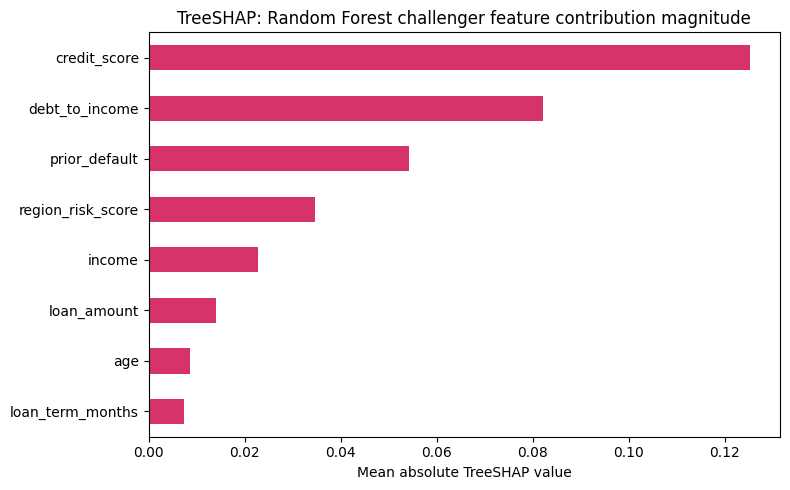

TreeSHAP executed


{'AUC': 0.78, 'Accuracy': 0.794}

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

rf_X_train = applications.iloc[train_idx][features].astype(float)
rf_X_test = applications.iloc[test_idx][features].astype(float)
rf_y_train = applications.iloc[train_idx]["default_next_12m"].astype(int)
rf_y_test = applications.iloc[test_idx]["default_next_12m"].astype(int)

rf_challenger = RandomForestClassifier(
    n_estimators=160,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=6822,
    n_jobs=-1,
)
rf_challenger.fit(rf_X_train, rf_y_train)
rf_prob = rf_challenger.predict_proba(rf_X_test)[:, 1]
rf_metrics_notebook = {
    "AUC": round(float(roc_auc_score(rf_y_test, rf_prob)), 3),
    "Accuracy": round(float(accuracy_score(rf_y_test, (rf_prob >= 0.5).astype(int))), 3),
}

try:
    try:
        import shap
    except ImportError:
        import sys
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
        import shap

    tree_sample = rf_X_test.head(200)
    tree_explainer = shap.TreeExplainer(rf_challenger)
    tree_values = tree_explainer.shap_values(tree_sample)
    if isinstance(tree_values, list):
        class_one_values = tree_values[1]
    elif getattr(tree_values, "ndim", 0) == 3:
        class_one_values = tree_values[:, :, 1]
    else:
        class_one_values = tree_values

    treeshap_importance = (
        pd.Series(np.abs(class_one_values).mean(axis=0), index=features)
        .sort_values(ascending=True)
    )
    ax = treeshap_importance.plot(kind="barh", figsize=(8, 5), color="#d6336c")
    ax.set_title("TreeSHAP: Random Forest challenger feature contribution magnitude")
    ax.set_xlabel("Mean absolute TreeSHAP value")
    plt.tight_layout()
    plt.savefig("Task3_notebook_treeshap_bar.png", dpi=100)
    plt.show()
    treeshap_status = "TreeSHAP executed"
except Exception as exc:
    fallback_importance = pd.Series(rf_challenger.feature_importances_, index=features).sort_values(ascending=True)
    ax = fallback_importance.plot(kind="barh", figsize=(8, 5), color="#868e96")
    ax.set_title("Random Forest feature importance fallback")
    ax.set_xlabel("Impurity-based importance")
    plt.tight_layout()
    plt.savefig("Task3_notebook_treeshap_bar.png", dpi=100)
    plt.show()
    treeshap_status = f"TreeSHAP unavailable; fallback RF importance used ({type(exc).__name__})"

print(treeshap_status)
rf_metrics_notebook


## Optional SHAP explainability

The assignment brief mentions SHAP/LIME as a reasonable way to demonstrate explainable AI. This cell first tries to import `shap`; if missing, it attempts a quiet local pip install. If installation is blocked, the notebook falls back to the linear model's transparent SHAP-style feature contributions so the prototype still runs end-to-end.


In [5]:
feature_names = ["intercept"] + features
explanation_sample = X_test[:5]

def predict_from_design_matrix(z):
    return 1 / (1 + np.exp(-(z @ weights)))

try:
    try:
        import shap
        import matplotlib.pyplot as plt
    except ImportError:
        import sys
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
        import shap
        import matplotlib.pyplot as plt
    background = X_train[:100]
    explainer = shap.Explainer(predict_from_design_matrix, background)
    shap_values = explainer(explanation_sample)
    explainability_output = pd.DataFrame(
        shap_values.values,
        columns=feature_names,
        index=[f"test_applicant_{i+1}" for i in range(len(explanation_sample))]
    ).round(4)
    explanation_method = "Package SHAP values"
except Exception as exc:
    contributions = explanation_sample * weights
    explainability_output = pd.DataFrame(
        contributions,
        columns=feature_names,
        index=[f"test_applicant_{i+1}" for i in range(len(explanation_sample))]
    ).round(4)
    explanation_method = f"SHAP unavailable; fallback linear contributions used ({type(exc).__name__})"

print(explanation_method)
explainability_output


Package SHAP values


,intercept,age,income,credit_score,debt_to_income,loan_amount,loan_term_months,prior_default,region_risk_score
test_applicant_1,0.0,0.0020,-0.0088,0.2853,-0.1699,0.0020,-0.0017,0.1418,0.0378
test_applicant_2,0.0,0.0017,0.0151,-0.0447,-0.0144,-0.0047,-0.0058,-0.0140,-0.0174
test_applicant_3,0.0,-0.0028,0.0046,-0.0623,-0.0154,-0.0022,0.0104,-0.0146,0.0052
test_applicant_4,0.0,0.0045,0.0112,0.0021,-0.0486,-0.0043,0.0024,-0.0162,-0.0057
test_applicant_5,0.0,-0.0038,-0.0155,-0.0819,-0.0218,0.0022,0.0017,-0.0117,0.0225


## Notebook SHAP visualization

This cell produces a notebook-native SHAP bar plot when package SHAP is available. If package SHAP could not run, it creates an equivalent bar chart from the fallback linear contributions so that the notebook still contains a visual explanation.


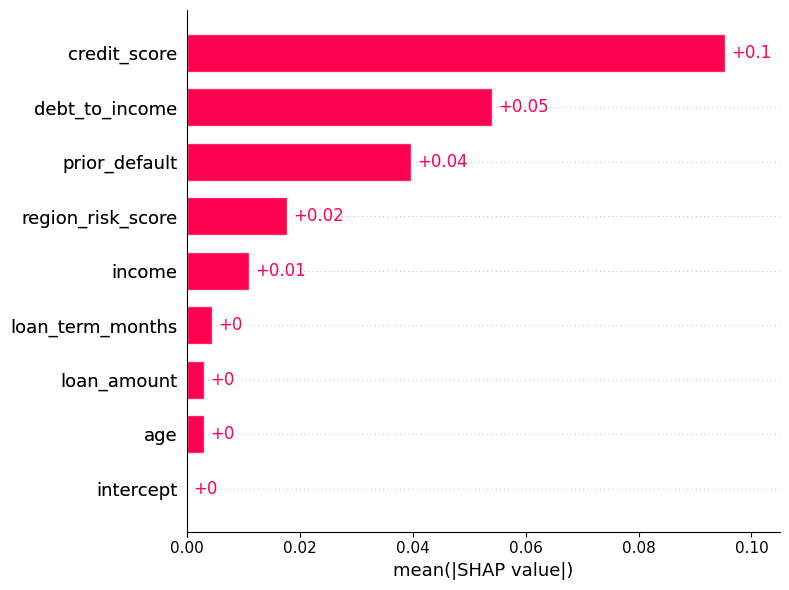

In [6]:
import matplotlib.pyplot as plt

if explanation_method == "Package SHAP values":
    raw_names = feature_names
    clean_names = [
        name.replace("num__", "")
            .replace("cat__", "")
            .replace("employment_status_", "employment_status=")
            .replace("loan_purpose_", "loan_purpose=")
        for name in raw_names
    ]
    try:
        shap_values.feature_names = clean_names
    except Exception:
        pass
    shap.plots.bar(shap_values, show=False)
    plt.tight_layout()
    plt.savefig("Task3_notebook_shap_bar.png", dpi=100)
    plt.show()
else:
    mean_abs = explainability_output.abs().mean().sort_values(ascending=True)
    ax = mean_abs.plot(kind="barh", figsize=(8, 5), color="#0b7285")
    ax.set_title("Fallback SHAP-style feature contribution magnitude")
    ax.set_xlabel("Mean absolute contribution")
    plt.tight_layout()
    plt.savefig("Task3_notebook_shap_bar.png", dpi=100)
    plt.show()


## SHAP-style explanations for rejected applicants

The generated package includes applicant-level linear SHAP-style contributions from the benchmark logistic-regression model. Positive values increase predicted default risk and are mapped to adverse-action reason categories.


In [7]:
shap_explanations.head(12)


,applicant_id,model_score,rank,technical_feature,linear_shap_log_odds,direction,mapped_consumer_reason
0,APP-00011,0.2834,1,debt_to_income,0.9182,increases predicted default risk,High debt-to-income ratio
1,APP-00011,0.2834,2,credit_score,0.3253,increases predicted default risk,Low credit score
2,APP-00011,0.2834,3,region_risk_score,0.1306,increases predicted default risk,Elevated regional portfolio risk
3,APP-00013,0.2535,1,credit_score,1.1200,increases predicted default risk,Low credit score
4,APP-00013,0.2535,2,debt_to_income,0.3562,increases predicted default risk,High debt-to-income ratio
5,APP-00013,0.2535,3,region_risk_score,0.0536,increases predicted default risk,Elevated regional portfolio risk
6,APP-00014,0.5230,1,debt_to_income,1.1278,increases predicted default risk,High debt-to-income ratio
7,APP-00014,0.5230,2,credit_score,1.0452,increases predicted default risk,Low credit score
8,APP-00014,0.5230,3,income,0.2095,increases predicted default risk,Income insufficient for requested loan


## Jurisdiction-aware output

The same approval data is evaluated under different regulatory thresholds and governance expectations. The EU 0.90 threshold is not a statutory AI Act threshold; it is Meridian's internal conservative governance escalation threshold, while legal obligations are mapped separately through Article 10 data governance, Article 14 human oversight and Article 17 quality-management controls.


In [8]:
metrics[[
    "active_jurisdiction", "metric_name", "protected_group_approval_rate",
    "reference_group_approval_rate", "approval_parity_ratio",
    "protected_group_false_positive_rate", "reference_group_false_positive_rate",
    "protected_group_false_negative_rate", "reference_group_false_negative_rate",
    "threshold",
    "fairness_flag", "required_governance_action"
]]


,active_jurisdiction,metric_name,protected_group_approval_rate,reference_group_approval_rate,approval_parity_ratio,protected_group_false_positive_rate,reference_group_false_positive_rate,protected_group_false_negative_rate,reference_group_false_negative_rate,threshold,fairness_flag,required_governance_action
0,US,disparate_impact_ratio,0.7305,0.825,0.8855,0.1927,0.1341,0.3937,0.4706,0.80,False,Continue monitoring adverse-action reason qual...
1,EU,approval_parity_ratio,0.7305,0.825,0.8855,0.1927,0.1341,0.3937,0.4706,0.90,True,"Trigger high-risk AI bias governance review, d..."
2,Singapore,internal_fairness_review,0.7305,0.825,0.8855,0.1927,0.1341,0.3937,0.4706,0.85,False,Continue accountable AI monitoring.
3,UK,outcome_gap,0.7305,0.825,0.8855,0.1927,0.1341,0.3937,0.4706,0.85,False,Continue outcome monitoring.


In [9]:
sample = outputs.loc[outputs["approved"].eq(0), [
    "applicant_id", "model_score", "decision_reason_1", "decision_reason_2",
    "us_mode_output", "eu_mode_output"
]].head(10)
sample


,applicant_id,model_score,decision_reason_1,decision_reason_2,us_mode_output,eu_mode_output
10,APP-00011,0.2834,High debt-to-income ratio,Elevated regional portfolio risk,Adverse-action notice required: High debt-to-i...,Bias testing and high-risk AI documentation ev...
12,APP-00013,0.2535,Low credit score,Elevated regional portfolio risk,Adverse-action notice required: Low credit sco...,Bias testing and high-risk AI documentation ev...
13,APP-00014,0.5230,Low credit score,High debt-to-income ratio,Adverse-action notice required: Low credit sco...,Bias testing and high-risk AI documentation ev...
23,APP-00024,0.4402,Low credit score,High debt-to-income ratio,Adverse-action notice required: Low credit sco...,Bias testing and high-risk AI documentation ev...
24,APP-00025,0.3311,High debt-to-income ratio,Low credit score,Adverse-action notice required: High debt-to-i...,Bias testing and high-risk AI documentation ev...
31,APP-00032,0.3900,Low credit score,Prior default history,Adverse-action notice required: Low credit sco...,Bias testing and high-risk AI documentation ev...
32,APP-00033,0.2173,High debt-to-income ratio,Elevated regional portfolio risk,Adverse-action notice required: High debt-to-i...,Human oversight required for borderline high-r...
36,APP-00037,0.3002,Low credit score,Elevated regional portfolio risk,Adverse-action notice required: Low credit sco...,Bias testing and high-risk AI documentation ev...
43,APP-00044,0.2179,Low credit score,Elevated regional portfolio risk,Adverse-action notice required: Low credit sco...,Human oversight required for borderline high-r...
45,APP-00046,0.3347,High debt-to-income ratio,Elevated regional portfolio risk,Adverse-action notice required: High debt-to-i...,Bias testing and high-risk AI documentation ev...


## Rule change mid-period simulation

This cell demonstrates how an internal jurisdiction rule change changes governance output. It simulates Meridian's EU governance threshold moving from 0.90 to 0.85 and compares the flag before and after the change.


In [10]:
approval_parity_ratio = metrics.loc[
    metrics["active_jurisdiction"].eq("EU"),
    "approval_parity_ratio"
].iloc[0]

old_threshold = metrics.loc[
    metrics["active_jurisdiction"].eq("EU"),
    "threshold"
].iloc[0]
new_threshold = 0.85

old_flag = approval_parity_ratio < old_threshold
new_flag = approval_parity_ratio < new_threshold

governance_effect = (
    "Escalation removed under updated threshold"
    if old_flag and not new_flag
    else "Escalation unchanged"
)

print("Rule change simulation")
print(f"Approval parity ratio: {approval_parity_ratio:.4f}")
print(f"Old EU threshold: {old_threshold:.2f}")
print(f"Old governance flag: {bool(old_flag)}")
print(f"Updated EU threshold: {new_threshold:.2f}")
print(f"Updated governance flag: {bool(new_flag)}")
print(f"Governance effect: {governance_effect}")


Rule change simulation
Approval parity ratio: 0.8855
Old EU threshold: 0.90
Old governance flag: True
Updated EU threshold: 0.85
Updated governance flag: False
Governance effect: Escalation removed under updated threshold


## Sensitivity analysis

The same tool can test how conclusions change if the protected-group score distribution shifts. This helps management see whether a governance conclusion is robust or sitting near a threshold.


In [11]:
sensitivity.pivot(
    index="protected_group_score_shift",
    columns="active_jurisdiction",
    values="fairness_flag"
)


active_jurisdiction,EU,US
protected_group_score_shift,,
-0.04,False,False
-0.02,False,False
0.00,True,False
0.02,True,False
0.04,True,True
0.06,True,True


## Interpretation

US mode prioritizes specific adverse-action explanation and fair-lending review. EU mode treats creditworthiness AI as a high-risk AI governance problem, so the same portfolio-level metric can trigger stricter bias-testing, documentation and human-oversight action.
